# Financial Data Structures

## Overview

This notebook demonstrates the public functions in `financial_data_structures` using a raw Alpaca trade file.

Key points:
- The notebook loads raw trade data from parquet.
- It resamples trades into multiple alternative bar types.
- It detects event timestamps with a CUSUM filter.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
sys.path.insert(0, str(root))

In [2]:
from src.data_preprocessing.financial_data_structures import (
    get_dollar_bars,
    get_dollar_imbalance_bars,
    get_dollar_run_bars,
    get_tick_bars,
    get_tick_imbalance_bars,
    get_tick_run_bars,
    get_volume_bars,
    get_volume_imbalance_bars,
    get_volume_run_bars,
    get_cusum_events,
)

## Load raw Alpaca trades

This section reads a user-specified AAPL trade file from `data/raw/alpaca/` and uses the full parquet dataset as the input trade stream.

Key points:
- The notebook keeps the `timestamp`, `symbol`, `price`, and `size` columns used by the bar-building functions.
- If you point `alpaca_path` at a different parquet file with the same schema, the rest of the notebook should still run without modification.

In [3]:
alpaca_path = root / "data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet"

trades = pd.read_parquet(alpaca_path).sort_values("timestamp").reset_index(drop=True)[["timestamp", "symbol", "price", "size"]].copy()

print(f"source: {alpaca_path.relative_to(root)}")
print(f"num_trades: {len(trades):,}")
trades.head()

source: data/raw/alpaca/stock_aapl_trades_20260101T000000Z_20260131T000000Z.parquet
num_trades: 406,489


,timestamp,symbol,price,size
0,2026-01-02 13:27:19.847471+00:00,AAPL,273.23,100.0
1,2026-01-02 14:08:22.630628+00:00,AAPL,272.96,2.0
2,2026-01-02 14:08:32.020709+00:00,AAPL,272.91,20.0
3,2026-01-02 14:08:32.020733+00:00,AAPL,272.91,5.0
4,2026-01-02 14:30:00.046988+00:00,AAPL,272.04,1.0


## Build And Compare Bars

This section builds nine bar variants and compares their closing-price paths.

Key points:
- Tick bar: closes after a fixed number of trades, so busy periods create bars faster in clock time.
- Volume bar: closes after cumulative traded size reaches a fixed threshold.
- Dollar bar: closes after cumulative traded notional reaches a fixed threshold.
- Tick imbalance bar: closes when signed trade direction becomes unusually one-sided relative to its expectation.
- Volume imbalance bar: closes when signed traded size becomes unusually one-sided relative to its expectation.
- Dollar imbalance bar: closes when signed traded notional becomes unusually one-sided relative to its expectation.
- Tick run bar: closes when a persistent buy or sell streak exceeds the expected balance.
- Volume run bar: closes when one side keeps dominating cumulative volume beyond its expectation.
- Dollar run bar: closes when one side keeps dominating cumulative traded notional beyond its expectation.
- Each bar result returns `sample`, which contains the trade rows where bars close.
- Each bar result also returns `ohlcv`, which contains aggregated `open`, `high`, `low`, `close`, `volume`, `dollar_value`, `ticks`, `buy_volume`, and `sell_volume` columns.

In [4]:
price = trades["price"].astype(float)
size = trades["size"].astype(float)
notional = price * size

standard_bar_target = 80
standard_thresholds = {
    "tick": max(1, len(trades) // standard_bar_target),
    "volume": float(size.sum() / standard_bar_target),
    "dollar": float(notional.sum() / standard_bar_target),
}

bar_results = {
    "Tick Bar": get_tick_bars(trades, threshold=standard_thresholds["tick"]),
    "Volume Bar": get_volume_bars(trades, threshold=standard_thresholds["volume"]),
    "Dollar Bar": get_dollar_bars(trades, threshold=standard_thresholds["dollar"]),
    "Tick Imbalance Bar": get_tick_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Volume Imbalance Bar": get_volume_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Dollar Imbalance Bar": get_dollar_imbalance_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Tick Run Bar": get_tick_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Volume Run Bar": get_volume_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
    "Dollar Run Bar": get_dollar_run_bars(trades, expected_num_ticks_init=1_000, expected_window=20),
}

pd.Series({name: len(result.ohlcv) for name, result in bar_results.items()}, name="num_bars").to_frame()

,num_bars
Tick Bar,80
Volume Bar,79
Dollar Bar,79
Tick Imbalance Bar,83
Volume Imbalance Bar,89
Dollar Imbalance Bar,88
Tick Run Bar,15136
Volume Run Bar,424
Dollar Run Bar,465


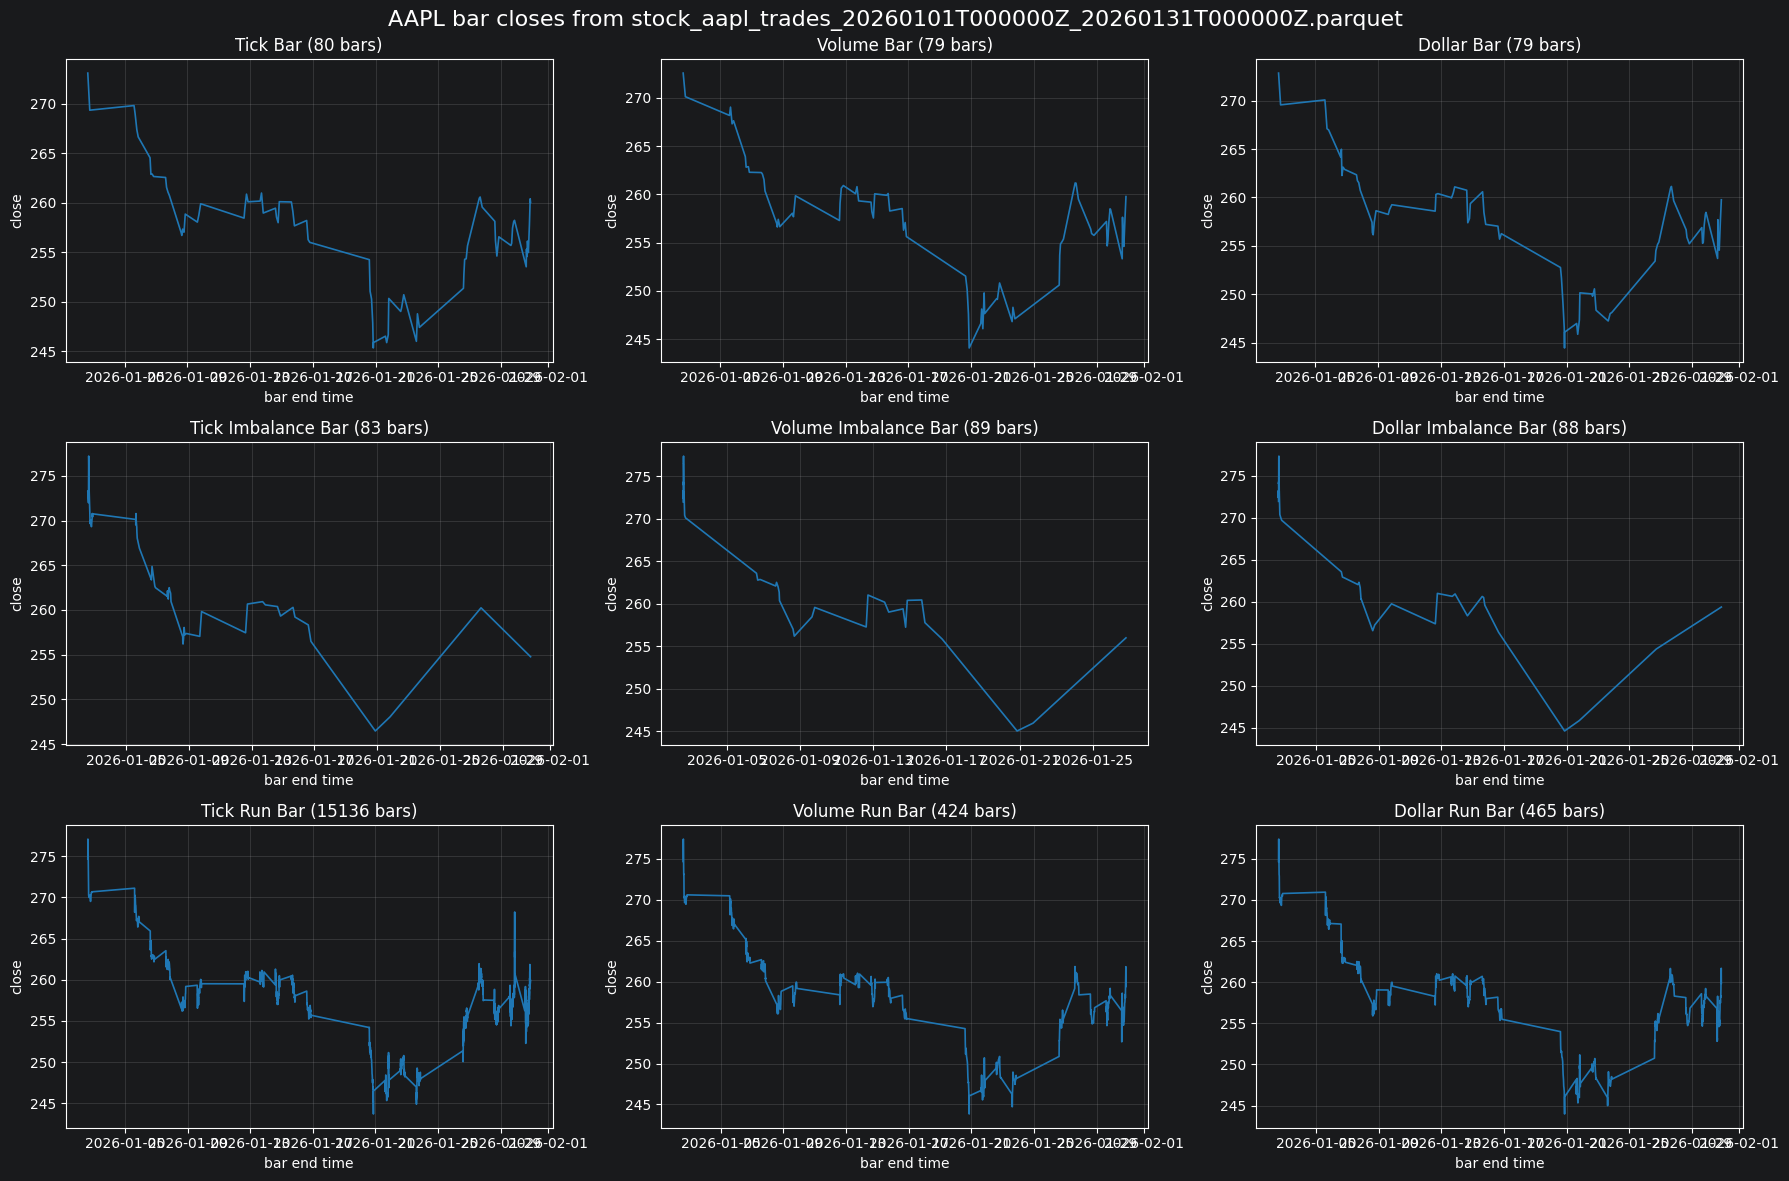

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12), sharex=False)
axes = axes.ravel()

for ax, (name, result) in zip(axes, bar_results.items()):
    ohlcv = result.ohlcv
    ax.plot(ohlcv.index, ohlcv["close"], color="tab:blue", linewidth=1.2)
    ax.set_title(f"{name} ({len(ohlcv)} bars)")
    ax.set_xlabel("bar end time")
    ax.set_ylabel("close")
    ax.grid(alpha=0.25)

fig.suptitle(f"AAPL bar closes from {alpaca_path.name}", fontsize=16)
fig.tight_layout()

In [6]:
bar_results["Tick Bar"].ohlcv.head()

,start,symbol,open,high,low,close,volume,dollar_value,ticks,buy_volume,sell_volume
end,,,,,,,,,,,
2026-01-02 15:47:56.808276+00:00,2026-01-02 13:27:19.847471+00:00,AAPL,273.23,277.79,271.95,273.100,378845.0,1.041830e+08,5081,204374.0,174471.0
2026-01-02 18:49:43.153292+00:00,2026-01-02 15:47:56.808318+00:00,AAPL,273.10,273.19,269.11,269.355,357171.0,9.655894e+07,5081,167173.0,189998.0
2026-01-05 14:32:07.959572+00:00,2026-01-02 18:49:43.324262+00:00,AAPL,269.36,271.49,269.10,269.820,369187.0,9.984359e+07,5081,185102.0,184085.0
2026-01-05 16:11:13.011943+00:00,2026-01-05 14:32:07.960633+00:00,AAPL,269.82,271.15,267.87,269.000,452552.0,1.218929e+08,5081,229769.0,222783.0
2026-01-05 18:48:46.261362+00:00,2026-01-05 16:11:13.916412+00:00,AAPL,268.99,269.35,266.79,267.390,418117.0,1.120364e+08,5081,201990.0,216127.0


## CUSUM event filter

This section applies `get_cusum_events` to detect timestamps where cumulative signed moves exceed a positive threshold.

Key points:
- The example uses the dollar-bar close series rather than the raw trade stream.
- That makes the event filter run on a smoother, already-resampled price path.
- The threshold is set to three times the median absolute close-to-close change.
- That choice keeps the example adaptive to the scale of the selected dataset while staying simple to explain.

In [7]:
dollar_close = bar_results["Dollar Bar"].ohlcv["close"]
cusum_threshold = float(dollar_close.diff().abs().median() * 3)
cusum_events = get_cusum_events(dollar_close, threshold=cusum_threshold)

print(f"cusum_threshold: {cusum_threshold:.4f}")
print(f"num_events: {len(cusum_events)}")
cusum_events[:10]

cusum_threshold: 3.2250
num_events: 19


DatetimeIndex(['2026-01-02 18:48:49.872071+00:00',
               '2026-01-06 14:36:26.869418+00:00',
               '2026-01-07 16:14:01.898374+00:00',
               '2026-01-08 14:32:06.845881+00:00',
               '2026-01-12 16:14:57.666428+00:00',
               '2026-01-14 16:55:05.187314+00:00',
               '2026-01-15 20:20:21.134333+00:00',
               '2026-01-20 14:36:57.908064+00:00',
               '2026-01-20 18:33:51.270242+00:00',
               '2026-01-20 20:46:59.892578+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

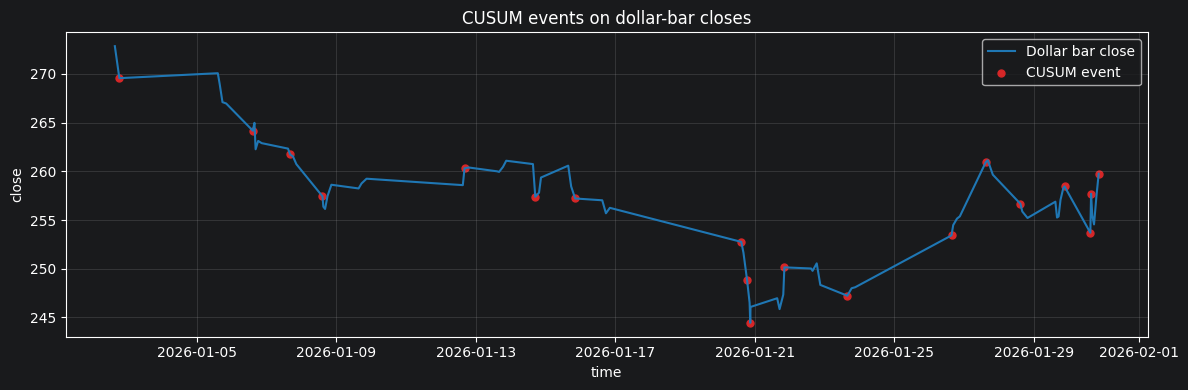

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dollar_close.index, dollar_close, label="Dollar bar close", color="tab:blue")
ax.scatter(cusum_events, dollar_close.loc[cusum_events], color="tab:red", s=25, label="CUSUM event")
ax.set_title("CUSUM events on dollar-bar closes")
ax.set_xlabel("time")
ax.set_ylabel("close")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()